# Xunzi finetune inference

Notebook này chạy inference cho mô hình **Xunzi (base + LoRA adapter)** để **phân từ (segmentation) + chèn dấu câu (punctuation)** cho văn bản cổ Hán.

**Luồng chính**
1. Cài đặt (nếu cần)
2. Imports & cấu hình đường dẫn
3. Utilities chuẩn hoá text
4. Retrieval (MinHash LSH, tuỳ chọn)
5. Post-processing output (loại `<think>...</think>`)
6. Metrics (seg F1, punc F1, fidelity, OSC)
7. Inference pipeline (sliding window + robust alignment)
8. Chạy thử & xuất kết quả

## 0) Cài đặt (chỉ khi cần)

In [1]:
# Cài đặt thư viện (bỏ qua nếu môi trường đã có sẵn)
!pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet
!pip install --no-deps "xformers" "trl<0.9.0" "accelerate" "bitsandbytes" --quiet
!pip install datasketch jiwer seqeval opencc-python-reimplemented --quiet

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.8/293.8 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 90.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 10.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the f

## 1) Imports & cấu hình

Cell này khai báo toàn bộ import dùng xuyên suốt notebook và cấu hình các đường dẫn model/data.

In [2]:
from unsloth import FastLanguageModel  # cần import trước khi load model (Unsloth)
import difflib
import json
import os
import re
from dataclasses import dataclass
from typing import Dict, List, Optional, Sequence
import numpy as np
import pandas as pd
import torch
from datasketch import MinHash, MinHashLSH
from jiwer import cer
from peft import PeftModel
from tqdm.auto import tqdm


@dataclass(frozen=True)
class Config:
    # --- Model paths ---
    base_model_dir: str = "/kaggle/input/xunzi-qwen3-8b/pytorch/default/1/Xunzi-Qwen3-8B"
    adapter_dir: str = (
        "/kaggle/input/xunzi-finetune/xunzi-qwen3-8b-finetune-evahan/"
    )

    # --- Data files ---
    # Khai báo trực tiếp đường dẫn (absolute/đúng môi trường chạy).
    train_files: Sequence[str] = (
        "/kaggle/input/evahan-2022/evahan_train.json",
        "/kaggle/input/wenyanbench/EvaHan/zuozhuan_train_utf8.json",
    )
    test_files: Sequence[str] = (
        "/kaggle/input/evahan-2022/evahan_testa.json",
        "/kaggle/input/evahan-2022/evahan_testb.json",
        "/kaggle/input/wenyanbench/EvaHan/EvaHan_testa_gold.json",
        "/kaggle/input/wenyanbench/EvaHan/EvaHan_testb_gold.json",
    )

    # --- Speado params ---
    max_seq_length: int = 1024
    chunk_size: int = 512
    overlap_size: int = 128
    num_perm: int = 128

    # --- Retrieval robustness (sync with training) ---
    retrieval_lsh_threshold: float = 0.5
    # Nếu best similarity < threshold => không chèn reference example vào prompt
    retrieval_min_score_threshold: float = 0.5

    # --- Decoding ---
    # NOTE: LogitsProcessor-based constraint decoding removed; we rely on post-hoc robust alignment.
    num_beams: int = 1

    # Whitelist punctuation
    PUNC_SET = set(
        [
            '"',
            '(',
            ')',
            ',',
            '-',
            ':',
            '、',
            '。',
            '〈',
            '〉',
            '《',
            '》',
            '「',
            '」',
            '『',
            '』',
            '〔',
            '〕',
            '\ue3ed',
            '\ue3f0',
            '\ue3ff',
            '！',
            '（',
            '）',
            '，',
            '．',
            '：',
            '；',
            '？',
        ]
    )

    puncs: frozenset = frozenset(PUNC_SET)
    seed: int = 42


CFG = Config()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


2026-01-04 08:03:16.529600: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767513796.943771      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767513797.065541      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1767513798.164842      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767513798.164883      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1767513798.164885      24 computation_placer.cc:177] computation placer alr

🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not import trl.trainer.ddpo_trainer: Failed to import trl.trainer.ddpo_trainer because of the following error (look up to see its traceback):
Failed to import trl.models.modeling_sd_base because of the following error (look up to see its traceback):
Failed to import diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion because of the following error (look up to see its traceback):
Failed to import diffusers.loaders.ip_adapter because of the following error (look up to see its traceback):
/usr/local/lib/python3.12/dist-packages/xformers/flash_attn_3/_C.so: undefined symbol: _ZNK3c106SymInt22maybe_as_int_slow_pathEv


/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


## 2) Utilities (chuẩn hoá text)

Các hàm dưới đây dùng để:
- Bỏ POS tag trong EvaHan output (vd: `/n`, `/v`)
- Tách riêng phần **raw characters** (không dấu câu/space) để đảm bảo pipeline **không làm thay đổi chữ gốc**
- Tách riêng phần **segmentation** và **punctuation** để tính metric

In [3]:
def strip_pos_tags(text: str) -> str:
    """Remove EvaHan POS tags like '/n', '/v' ... and normalize spacing."""
    no_tags = re.sub(r"/[a-z]+", "", text)
    no_tags = re.sub(r"\s+", " ", no_tags).strip()
    return no_tags


def strip_punc_and_spaces(text: str) -> str:
    """Remove whitelisted punctuation and spaces; keep only raw characters."""
    # Dùng để kiểm tra/đảm bảo raw characters không bị thay đổi bởi model.
    return "".join(ch for ch in text if ch not in CFG.puncs and ch != " ")


def seg_only(text: str) -> str:
    """Keep spaces (segmentation), remove punctuation."""
    return "".join(ch for ch in text if ch not in CFG.puncs)


def punc_only(text: str) -> str:
    """Keep punctuation, remove spaces (normalize whitespace first)."""
    text = re.sub(r"\s+", " ", text).strip()
    return text.replace(" ", "")

## 3) Retrieval (MinHash LSH) — tuỳ chọn

Mục tiêu: tìm 1 mẫu trong train có raw characters “gần giống” input để đưa vào prompt (few-shot).
Nếu độ giống nhau thấp hơn ngưỡng (`retrieval_min_score_threshold`) thì **không chèn reference** (đúng với training).

In [4]:
class SpeadoRetriever:
    """
    Retriever used at inference time (kept consistent with training).

    Key upgrades (SOTA hygiene):
    - Use MinHashLSH only for candidate pruning (fast).
    - Re-score candidates by actual similarity (Jaccard on char-set; robust & cheap).

    IMPORTANT (sync with training):
    - Only return a reference example if similarity >= CFG.retrieval_min_score_threshold.
    - Otherwise return an empty string (no reference block).

    Output format (match finetune prompt):
    - Return Chinese example section with lines:
      `原文：...` and `标注：...`
    """

    def __init__(
        self,
        train_paths: Sequence[str],
        *,
        threshold: float = 0.5,
        min_score_threshold: float = 0.5,
    ):
        self.lsh = MinHashLSH(threshold=threshold, num_perm=CFG.num_perm)
        self.min_score_threshold = float(min_score_threshold)
        self._target_by_id: Dict[str, str] = {}
        self._char_set_by_id: Dict[str, set] = {}

        paths = list(train_paths)
        if not paths:
            raise ValueError("train_paths is empty")

        data: List[dict] = []
        missing: List[str] = []
        for p in paths:
            if not os.path.exists(p):
                missing.append(p)
                continue
            with open(p, "r", encoding="utf-8") as f:
                part = json.load(f)
                if isinstance(part, list):
                    data.extend(part)
                else:
                    raise ValueError(f"Train file must be a JSON list: {p}")
        if missing:
            raise FileNotFoundError("Train file(s) not found: " + ", ".join(missing))

        # Index train outputs by their raw characters (punctuation/space removed).
        for idx, item in enumerate(tqdm(data, desc="Indexing train")):
            target = strip_pos_tags(item["output"])
            raw = strip_punc_and_spaces(target)
            mh = MinHash(num_perm=CFG.num_perm)
            for ch in raw:
                mh.update(ch.encode("utf-8"))

            key = str(idx)
            self.lsh.insert(key, mh)
            self._target_by_id[key] = target
            self._char_set_by_id[key] = set(raw)

    @staticmethod
    def _jaccard_char_set(a: str, b: str) -> float:
        # Helper for debugging/experiments (not used in main path).
        sa = set(a)
        sb = set(b)
        if not sa and not sb:
            return 1.0
        if not sa or not sb:
            return 0.0
        union = len(sa | sb)
        return (len(sa & sb) / union) if union else 0.0

    def best_example_block(self, query_raw: str) -> str:
        """
        Return a reference example section if it is similar enough.
        Otherwise return "" (no reference), to match the training-time behavior.
        """
        mh = MinHash(num_perm=CFG.num_perm)
        for ch in query_raw:
            mh.update(ch.encode("utf-8"))

        candidates = self.lsh.query(mh)
        if not candidates:
            return ""

        query_set = set(query_raw)
        best_score = -1.0
        best_id: Optional[str] = None

        # Re-score using exact Jaccard on character sets (more reliable than MinHash estimate).
        for cid in candidates:
            cand_set = self._char_set_by_id[cid]
            union = len(query_set | cand_set)
            score = (len(query_set & cand_set) / union) if union else 0.0
            if score > best_score:
                best_score = float(score)
                best_id = cid

        # Sync with training: only provide reference example if score >= threshold.
        threshold = float(getattr(CFG, "retrieval_min_score_threshold", 0.5))
        if best_id is None or best_score < threshold:
            return ""

        ref = self._target_by_id[best_id]
        ref_raw = strip_punc_and_spaces(ref)

        # Avoid leaking exact match (no hint needed).
        if ref_raw == query_raw:
            return ""

        # Match finetune formatter: Chinese labels
        return f"原文：{ref_raw}\n标注：{ref}"

## 4) Post-processing output

Model có thể sinh kèm các token/đoạn suy luận như `<think>...</think>` hoặc artifacts của ChatML.
Cell này chuẩn hoá output để pipeline phía sau chỉ làm việc với phần **response text**.

In [5]:
import re


def clean_model_output(text: str) -> str:
    """
    Remove `<think>...</think>` blocks and common ChatML artifacts.

    This is a *pure* string cleanup step; it does not change the raw characters in the input.
    """
    # Nếu prompt template có chia rõ input/response
    if "### Response:" in text:
        text = text.split("### Response:")[-1]
    elif "<|im_start|>assistant" in text:  # ChatML
        text = text.split("<|im_start|>assistant")[-1]

    # Pattern tìm thẻ <think> và mọi thứ bên trong nó (kể cả xuống dòng - re.DOTALL)
    pattern = r"<think>.*?</think>"
    cleaned_text = re.sub(pattern, "", text, flags=re.DOTALL)

    # Xoá artifacts phổ biến của ChatML/Qwen nếu còn sót
    cleaned_text = cleaned_text.replace("<|im_end|>", "").replace("<|endoftext|>", "")

    return cleaned_text.strip()

## 5) Metrics

Tính các metric sau cho từng mẫu:
- `seg_f1`: F1 cho segmentation (bỏ dấu câu)
- `punc_f1`: F1 cho punctuation (bỏ space)
- `punc_and_seg_f1`: F1 cho nhãn kết hợp segmentation + punctuation (tính trực tiếp từ `pred_full` vs `gt_full`)
- `fidelity`: $1 - CER$ trên raw characters (phạt nếu model làm sai chữ)
- `osc`: tích `fidelity * seg_f1 * punc_f1`

In [6]:
from seqeval.metrics import f1_score
from typing import Dict, List


class Metrics:
    """Metrics for Ancient Chinese Segmentation & Punctuation.

    Requirements:
    - Use `seg_only(...)` for segmentation scoring (ignore punctuation).
    - Use `punc_only(...)` for punctuation scoring (ignore spaces).

    Punctuation tagging notes:
    - Multiple punctuations may occur consecutively after the same raw char (e.g. `。”`).
    - We assign punctuation labels to the immediately preceding raw character.
    - If multiple punctuations map to the same raw char, keep the higher-priority one.
      If priorities tie, keep the first tag (first-win).
    """

    # Mapping punctuation -> label names (seqeval "entity" labels)
    PUNC_MAP = {
        # --- Basic ---
        "，": "COMMA",
        ",": "COMMA",
        "、": "PAUSE",
        "。": "PERIOD",
        "．": "DOT",
        "！": "EXCLAM",
        "？": "QUEST",
        "；": "SEMICOLON",
        "：": "COLON",
        ":": "COLON",
        "-": "HYPHEN",

        # --- Brackets & quotes ---
        "“": "QUOTE_L",
        "”": "QUOTE_R",
        "\"": "QUOTE",
        "（": "PAREN_L",
        "(": "PAREN_L",
        "）": "PAREN_R",
        ")": "PAREN_R",
        "《": "BOOK_L",
        "》": "BOOK_R",
        "〈": "ANGLE_L",
        "〉": "ANGLE_R",
        "「": "CORNER_L",
        "」": "CORNER_R",
        "『": "CORNER_W_L",
        "』": "CORNER_W_R",
        "〔": "TORTOISE_L",
        "〕": "TORTOISE_R",

        # --- PUA / dataset artifacts ---
        "\ue3ed": "PUA_ED",
        "\ue3f0": "PUA_F0",
        "\ue3ff": "PUA_FF",
    }

    # Higher value => more important; defaults to 1 for unknown/other punctuation.
    PUNC_PRIORITY = {
        # Sentence-ending / strong breaks
        "PERIOD": 3,
        "QUEST": 3,
        "EXCLAM": 3,
        # Clause / weaker breaks
        "COMMA": 2,
        "SEMICOLON": 2,
        "PAUSE": 2,
    }

    @staticmethod
    def _seg_tags_from_seg_only(seg_text: str) -> List[str]:
        """Convert `seg_only(text)` into BIO tags over raw characters."""
        tags: List[str] = []
        start_of_word = True
        for ch in seg_text:
            if ch == " ":
                start_of_word = True
                continue
            tags.append("B-W" if start_of_word else "I-W")
            start_of_word = False
        return tags

    @staticmethod
    def _punc_tags_from_punc_only(punc_text: str, puncs: set) -> List[str]:
        """Convert `punc_only(text)` into per-raw-character punctuation tags."""
        tags: List[str] = []
        last_raw_index = -1
        for ch in punc_text:
            if ch in puncs:
                # Assign punctuation to the immediately preceding raw character.
                if last_raw_index >= 0:
                    new_name = Metrics.PUNC_MAP.get(ch, "PUNC")
                    new_tag = f"B-{new_name}"
                    current_tag = tags[last_raw_index]
                    if current_tag == "O":
                        tags[last_raw_index] = new_tag
                    else:
                        # Collision: keep the higher-priority punctuation tag.
                        current_name = (
                            current_tag[2:] if current_tag.startswith("B-") else current_tag
                        )
                        cur_p = int(Metrics.PUNC_PRIORITY.get(current_name, 1))
                        new_p = int(Metrics.PUNC_PRIORITY.get(new_name, 1))
                        if new_p > cur_p:
                            tags[last_raw_index] = new_tag
                continue

            # Raw character
            tags.append("O")
            last_raw_index += 1
        return tags

    @staticmethod
    def _joint_tags_from_full_text(full_text: str, puncs: set) -> List[str]:
        """
        Joint tagging for segmentation + punctuation from `pred_full`/`gt_full`.
        
        Representation: BIO over raw characters, where each *word* is an entity type `W__<PUNC>`.
        `<PUNC>` is chosen as the highest-priority punctuation that appears after the word's last raw char.
        If no punctuation exists for the word, `<PUNC>` = `NOPUNC`.
        
        This keeps valid BIO sequences (punctuation label is constant within a word).
        """
        s = re.sub(r"\s+", " ", (full_text or "").strip())
        tags: List[str] = []

        word_start: Optional[int] = None
        word_len = 0
        best_punc_name = "NOPUNC"
        best_punc_pri = 0

        def flush_word():
            nonlocal word_start, word_len, best_punc_name, best_punc_pri
            if word_start is None or word_len <= 0:
                word_start = None
                word_len = 0
                best_punc_name = "NOPUNC"
                best_punc_pri = 0
                return
            ent_type = f"W__{best_punc_name}"
            for i in range(word_len):
                prefix = "B" if i == 0 else "I"
                tags[word_start + i] = f"{prefix}-{ent_type}"
            word_start = None
            word_len = 0
            best_punc_name = "NOPUNC"
            best_punc_pri = 0

        for ch in s:
            if ch == " ":
                flush_word()
                continue

            if ch in puncs:
                # Only count punctuation when we are inside a word.
                if word_start is not None:
                    name = Metrics.PUNC_MAP.get(ch, "PUNC")
                    pri = int(Metrics.PUNC_PRIORITY.get(name, 1))
                    if pri > best_punc_pri:
                        best_punc_pri = pri
                        best_punc_name = name
                continue

            # Raw character
            if word_start is None:
                word_start = len(tags)
                word_len = 0
                best_punc_name = "NOPUNC"
                best_punc_pri = 0
            tags.append("O")  # placeholder; overwritten in flush_word()
            word_len += 1

        flush_word()
        return tags

    @staticmethod
    def compute(pred_full: str, gt_full: str, puncs: set) -> Dict[str, float]:
        """Compute seg_f1, punc_f1, fidelity, osc."""
        pred_full = (pred_full or "").strip()
        gt_full = (gt_full or "").strip()

        # Fidelity: raw character preservation (penalize if any char mismatch).
        pred_raw = strip_punc_and_spaces(pred_full)
        gt_raw = strip_punc_and_spaces(gt_full)
        try:
            fidelity = max(0.0, 1.0 - float(cer(gt_raw, pred_raw)))
        except Exception:
            fidelity = 0.0

        # Segmentation tags from seg_only(...)
        p_seg = Metrics._seg_tags_from_seg_only(seg_only(pred_full))
        t_seg = Metrics._seg_tags_from_seg_only(seg_only(gt_full))

        # Punctuation tags from punc_only(...)
        p_punc = Metrics._punc_tags_from_punc_only(punc_only(pred_full), puncs)
        t_punc = Metrics._punc_tags_from_punc_only(punc_only(gt_full), puncs)

        # Joint tags over full text: segmentation + punctuation
        p_joint = Metrics._joint_tags_from_full_text(pred_full, puncs)
        t_joint = Metrics._joint_tags_from_full_text(gt_full, puncs)

        # Seqeval requires equal lengths; clamp and set fidelity=0 as a hard penalty.
        if (
            len(p_seg) != len(t_seg)
            or len(p_punc) != len(t_punc)
            or len(p_joint) != len(t_joint)
        ):
            min_len = min(
                len(p_seg), len(t_seg), len(p_punc), len(t_punc), len(p_joint), len(t_joint)
            )
            p_seg, t_seg = p_seg[:min_len], t_seg[:min_len]
            p_punc, t_punc = p_punc[:min_len], t_punc[:min_len]
            p_joint, t_joint = p_joint[:min_len], t_joint[:min_len]
            fidelity = 0.0

        seg_f1 = float(f1_score([t_seg], [p_seg])) if t_seg else 0.0
        punc_f1 = float(f1_score([t_punc], [p_punc])) if t_punc else 0.0
        punc_and_seg_f1 = float(f1_score([t_joint], [p_joint])) if t_joint else 0.0
        osc = fidelity * seg_f1 * punc_f1

        return {
            "seg_f1": seg_f1,
            "punc_f1": punc_f1,
            "punc_and_seg_f1": punc_and_seg_f1,
            "fidelity": fidelity,
            "osc": osc,
        }

## 6) Inference pipeline

Pipeline chạy theo 2 ý chính:
- **Sliding window (keep-center)**: xử lý văn bản dài bằng cách chia cửa sổ, chỉ giữ phần “an toàn” ở giữa để giảm lỗi biên.
- **Robust alignment (difflib)**: sau khi decode, căn chỉnh lại để đảm bảo **raw characters giữ nguyên tuyệt đối** (chỉ được chèn dấu câu/space).

In [7]:
# --- Sliding Window + Post-hoc Robust Alignment ---
import torch
from tqdm.auto import tqdm

# --- PROMPT TEMPLATE (match finetune; dynamic injection for reference) ---
# Filter/pretty-print valid punctuation list (space-separated) for explicit constraints.
filtered_punct = [c for c in CFG.puncs if len(c.encode("utf-8")) < 4 and c.isprintable()]
valid_puncts_str = " ".join(sorted(filtered_punct))

PROMPT_TEMPLATE = """<|im_start|>system
你是一个专业的古代汉语智能助手，专注于古文的“分词”与“标点”任务。

任务要求：
1. **分词规范**：依照EvaHan学术标准，词与词之间使用半角空格 " " 分隔。
2. **标点规范**：仅使用指定标点集合：{valid_puncts}，标点附着在词后，并在标点后添加空格。
3. **原文忠实**：严禁修改、增加或删除原文中的任何汉字，必须保持字符级别的绝对一致。

{sys_ref_instruction}
<|im_end|>
<|im_start|>user
{ref_block}### 待处理文本：
{input}
<|im_end|>
<|im_start|>assistant
"""


def build_chat_prompt(input_text: str, example_section: str = "") -> str:
    """Manual ChatML prompt with open assistant turn (no trailing <|im_end|>)."""
    example_section = (example_section or "").strip()
    has_ref = bool(example_section)
    sys_ref_instruction = "请借鉴下文相似范例，学习其断句逻辑与标点模式，并应用于当前标注任务。" if has_ref else ""
    ref_block = f"### 参考范例：\n{example_section}\n\n" if has_ref else ""
    return (
        PROMPT_TEMPLATE.format(
            valid_puncts=valid_puncts_str,
            sys_ref_instruction=sys_ref_instruction,
            ref_block=ref_block,
            input=input_text,
        )
        + "\n"
    )


def _load_model_and_tokenizer():
    """Load base model + LoRA adapter (Unsloth first, fallback to PEFT)."""
    try:
        model, tokenizer = FastLanguageModel.from_pretrained(
            CFG.base_model_dir,
            max_seq_length=CFG.max_seq_length,
            load_in_4bit=True,
        )
        model.load_adapter(CFG.adapter_dir)
        FastLanguageModel.for_inference(model)
        return model, tokenizer
    except Exception:
        from transformers import AutoModelForCausalLM, AutoTokenizer

        model = AutoModelForCausalLM.from_pretrained(
            CFG.base_model_dir,
            load_in_4bit=True,
            device_map="auto",
        )
        model = PeftModel.from_pretrained(model, CFG.adapter_dir)
        tokenizer = AutoTokenizer.from_pretrained(CFG.base_model_dir)
        return model, tokenizer


def _load_json_list_files(paths: Sequence[str]) -> List[dict]:
    """Load and concat multiple JSON-list files."""
    data: List[dict] = []
    missing: List[str] = []
    for p in list(paths):
        if not os.path.exists(p):
            missing.append(p)
            continue
        with open(p, "r", encoding="utf-8") as f:
            part = json.load(f)
            if isinstance(part, list):
                data.extend(part)
            else:
                raise ValueError(f"Expected JSON list in file: {p}")
    if missing:
        raise FileNotFoundError("Missing file(s): " + ", ".join(missing))
    return data


def _load_test_data() -> List[dict]:
    return _load_json_list_files(CFG.test_files)


class InferencePipeline:
    """
    Pipeline: Sliding Window inference + post-hoc robust alignment.

    Core invariant: `robust_align(raw_chunk, decoded)` guarantees
    `strip_punc_and_spaces(pred_chunk) == raw_chunk` (raw characters preserved exactly).
    """

    # ALLOWED_PUNCS = PUNC_SET + space 
    ALLOWED_PUNCS = set(CFG.puncs) | {" "}

    def __init__(self, model, tokenizer, chunk_size: int = 1024, overlap: int = 256):
        if chunk_size <= 0:
            raise ValueError(f"chunk_size must be > 0, got {chunk_size}")
        if overlap < 0:
            raise ValueError(f"overlap must be >= 0, got {overlap}")
        if overlap >= chunk_size:
            raise ValueError(
                f"overlap ({overlap}) must be < chunk_size ({chunk_size})"
            )

        self.model = model
        self.tokenizer = tokenizer
        self.chunk_size = int(chunk_size)
        self.overlap = int(overlap)
        self.max_seq_length = int(getattr(CFG, "max_seq_length", 1024))

        # Optional: attach externally (SpeadoRetriever)
        self.retriever = None

        # Choose device safely (avoid hardcoding cuda)
        self.device = getattr(model, "device", None)
        if self.device is None:
            self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        # Cache special token ids for stopping
        self._eos_ids = self._resolve_eos_ids()

    def _resolve_eos_ids(self):
        eos_ids = []
        if getattr(self.tokenizer, "eos_token_id", None) is not None:
            eos_ids.append(int(self.tokenizer.eos_token_id))
        try:
            im_end_id = self.tokenizer.convert_tokens_to_ids("<|im_end|>")
            if isinstance(im_end_id, int) and im_end_id >= 0:
                eos_ids.append(int(im_end_id))
        except Exception:
            pass
        return list(dict.fromkeys(eos_ids)) or None

    def _truncate_to_tokens(self, text: str, max_tokens: int) -> str:
        if max_tokens <= 0:
            return ""
        ids = self.tokenizer.encode(text, add_special_tokens=False)
        if len(ids) <= max_tokens:
            return text
        return self.tokenizer.decode(ids[:max_tokens], skip_special_tokens=True)

    def robust_align(self, raw_chunk: str, model_output: str) -> str:
        """
        Post-process model output so raw characters match raw_chunk exactly.
        Only allow punctuation insertions from ALLOWED_PUNCS (including whitespace).
        """
        # Clean <think> blocks and ChatML artifacts (string-only cleanup).
        model_output = clean_model_output(model_output)

        matcher = difflib.SequenceMatcher(None, raw_chunk, model_output)
        out: List[str] = []
        for tag, i1, i2, j1, j2 in matcher.get_opcodes():
            if tag == "equal":
                out.append(raw_chunk[i1:i2])
            elif tag == "insert":
                out.append("".join(c for c in model_output[j1:j2] if c in self.ALLOWED_PUNCS))
            elif tag == "replace":
                out.append(
                    raw_chunk[i1:i2]
                    + "".join(c for c in model_output[j1:j2] if c in self.ALLOWED_PUNCS)
                )
            elif tag == "delete":
                out.append(raw_chunk[i1:i2])
        return "".join(out)

    def _normalize_example_text(self, text: str) -> str:
        # Backward-compat: handle older retriever formats if present.
        s = (text or "").strip()
        if not s:
            return ""
        if s.startswith("### 参考范例："):
            s = s.split("\n", 1)[1].strip() if "\n" in s else ""
        return s.strip()

    def _count_tokens(self, prompt: str) -> int:
        ids = self.tokenizer(prompt, add_special_tokens=False).input_ids
        return len(ids)

    def _build_prompt_with_budget(self, input_text: str, example_section: str) -> str:
        """
        Critical rule: NEVER truncate input_text.
        If prompt exceeds max_seq_length, truncate example_section first.
        """
        base_prompt = build_chat_prompt(input_text=input_text, example_section="")
        base_len = self._count_tokens(base_prompt)
        if base_len > self.max_seq_length:
            raise ValueError(
                f"Input chunk too long for context window (tokens={base_len} > {self.max_seq_length}). "
                "Reduce chunk_size/overlap."
            )

        budget = self.max_seq_length - base_len
        ex = self._truncate_to_tokens(example_section, budget) if budget > 0 else ""
        prompt = build_chat_prompt(input_text=input_text, example_section=ex)
        if self._count_tokens(prompt) > self.max_seq_length:
            prompt = base_prompt
        return prompt

    def _predict_chunk(self, text: str) -> str:
        """Generate prediction then robust-align to preserve raw chars exactly."""
        example_section = ""
        if self.retriever is not None:
            try:
                example_section = self._normalize_example_text(
                    self.retriever.best_example_block(text)
                )
            except Exception:
                example_section = ""

        prompt = self._build_prompt_with_budget(input_text=text, example_section=example_section)
        inputs = self.tokenizer(
            [prompt],
            return_tensors="pt",
            add_special_tokens=False,
            truncation=False,
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}
        prompt_len = int(inputs["input_ids"].shape[1])

        # Dynamic max_new_tokens (~1.5x input chars)
        max_new_tokens = max(128, int(len(text) * 1.5) + 64)
        max_new_tokens = min(2048, max_new_tokens)

        with torch.no_grad():
            out_ids = self.model.generate(
                **inputs,
                do_sample=False,
                num_beams=int(getattr(CFG, "num_beams", 1)),
                max_new_tokens=max_new_tokens,
                repetition_penalty=1.1,
                pad_token_id=self.tokenizer.eos_token_id,
                eos_token_id=self._eos_ids,
            )

        gen_ids = out_ids[0][prompt_len:]
        decoded = self.tokenizer.decode(gen_ids, skip_special_tokens=False)
        decoded = decoded.replace("<|im_end|>", "")
        decoded = decoded.strip("\n\r")
        return self.robust_align(text, decoded)

    def _slice_by_raw_count(self, text_with_punc: str, skip_raw: int, keep_raw: int) -> str:
        """Slice by counting only raw (non-punctuation) characters."""
        if keep_raw <= 0:
            return ""
        if skip_raw < 0:
            raise ValueError(f"skip_raw must be >= 0, got {skip_raw}")

        raw_counter = 0
        kept_raw = 0
        started = False
        out: List[str] = []

        for ch in text_with_punc:
            if ch in self.ALLOWED_PUNCS:
                if started:
                    out.append(ch)
                continue

            if raw_counter < skip_raw:
                raw_counter += 1
                continue

            if kept_raw < keep_raw:
                started = True
                out.append(ch)
                kept_raw += 1
                raw_counter += 1
                continue

            break

        return "".join(out)

    def predict_long_text(self, long_raw_text: str) -> str:
        """
        Sliding-window inference with "keep center" strategy.
        Keeps raw characters unchanged via `robust_align` + raw-count slicing.
        """
        n = len(long_raw_text)
        if n == 0:
            return ""

        chunk_size = int(self.chunk_size)
        overlap = int(self.overlap)
        stride = chunk_size - 2 * overlap
        if stride <= 0:
            raise ValueError(
                f"Invalid keep-center config: stride={stride} "
                f"(chunk_size={chunk_size}, overlap={overlap}). "
                "Require chunk_size > 2*overlap. Reduce overlap or increase chunk_size."
            )

        if n <= chunk_size:
            pred = self._predict_chunk(long_raw_text)
            return self.robust_align(long_raw_text, pred)

        final_parts: List[str] = []

        # 1) First window: keep its left part (up to chunk_size - overlap raw chars).
        first_chunk_raw = long_raw_text[0:chunk_size]
        first_pred = self._predict_chunk(first_chunk_raw)
        first_aligned = self.robust_align(first_chunk_raw, first_pred)
        part_1 = self._slice_by_raw_count(
            first_aligned, skip_raw=0, keep_raw=chunk_size - overlap
        )
        final_parts.append(part_1)

        current_raw_idx = chunk_size - overlap

        # 2) Middle/last windows: keep the center core (stride).
        while current_raw_idx < n:
            start = current_raw_idx - overlap
            end = min(n, start + chunk_size)

            chunk_raw = long_raw_text[start:end]
            pred = self._predict_chunk(chunk_raw)
            aligned = self.robust_align(chunk_raw, pred)

            is_last = end == n
            skip_r = overlap
            keep_r = stride
            if is_last:
                keep_r = len(chunk_raw) - overlap

            core_part = self._slice_by_raw_count(aligned, skip_raw=skip_r, keep_raw=keep_r)
            final_parts.append(core_part)

            current_raw_idx += keep_r
            if is_last:
                break

        return "".join(final_parts)


def run_pipeline(
    output_csv: str = "speado_results.csv",
    num_samples: Optional[int] = None,
    ) -> pd.DataFrame:
    """Run inference pipeline and export per-sample outputs + metrics."""
    print("[Infer] Loading model...")
    model, tokenizer = _load_model_and_tokenizer()

    retriever = None
    try:
        print("[Retrieval] Building retrieval index...")
        retriever = SpeadoRetriever(
            CFG.train_files,
            threshold=float(getattr(CFG, "retrieval_lsh_threshold", 0.5)),
            min_score_threshold=float(getattr(CFG, "retrieval_min_score_threshold", 0.5)),
        )
    except Exception as e:
        print(f"[Warn][Retrieval] Retriever disabled: {e}")

    pipeline = InferencePipeline(
        model=model,
        tokenizer=tokenizer,
        chunk_size=getattr(CFG, "chunk_size", 1024),
        overlap=getattr(CFG, "overlap_size", 256),
    )
    pipeline.retriever = retriever

    data = _load_test_data()
    if num_samples is not None:
        if num_samples <= 0:
            raise ValueError("num_samples must be a positive integer or None")
        data = data[:num_samples]
    print(f"[Infer] Running inference on {len(data)} samples...")

    rows: List[dict] = []
    seg_f1s: List[float] = []
    punc_f1s: List[float] = []
    punc_and_seg_f1s: List[float] = []
    fidelities: List[float] = []
    oscs: List[float] = []

    for sample in tqdm(data, desc="Infer"):
        gt_full = strip_pos_tags(sample["output"])
        original = strip_punc_and_spaces(gt_full)
        pred_full = pipeline.predict_long_text(original)

        m = Metrics.compute(pred_full, gt_full, CFG.puncs)
        seg_f1 = float(m["seg_f1"])
        punc_f1 = float(m["punc_f1"])
        punc_and_seg_f1 = float(m["punc_and_seg_f1"])
        fidelity = float(m["fidelity"])
        osc = float(m["osc"])

        seg_f1s.append(seg_f1)
        punc_f1s.append(punc_f1)
        punc_and_seg_f1s.append(punc_and_seg_f1)
        fidelities.append(fidelity)
        oscs.append(osc)

        rows.append(
            {
                "original": original,
                "gt_full": gt_full,
                "gt_seg": seg_only(gt_full),
                "gt_punc": punc_only(gt_full),
                "pred_full": pred_full,
                "pred_seg": seg_only(pred_full),
                "pred_punc": punc_only(pred_full),
                "seg_f1": seg_f1,
                "punc_f1": punc_f1,
                "punc_and_seg_f1": punc_and_seg_f1,
                "fidelity": fidelity,
                "osc": osc,
            },
        )

    df = pd.DataFrame(rows)
    df.to_csv(output_csv, index=False)
    print(f"[Output] Saved: {output_csv}")

    if rows:
        print(
            f"[Metrics] Mean seg_f1={float(np.mean(seg_f1s)):.4f}  "
            f"punc_f1={float(np.mean(punc_f1s)):.4f}  "
            f"punc_and_seg_f1={float(np.mean(punc_and_seg_f1s)):.4f}  "
            f"fidelity={float(np.mean(fidelities)):.4f}  "
            f"osc={float(np.mean(oscs)):.6f}"
        )

    return df

## 7) Chạy thử

Chạy một số mẫu để sanity-check pipeline và xem nhanh output/metrics.

In [8]:
df = run_pipeline()
df.head()

[Infer] Loading model...
==((====))==  Unsloth 2025.12.10: Fast Qwen3 patching. Transformers: 4.57.1.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.4.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

[Retrieval] Building retrieval index...


Indexing train:   0%|          | 0/9570 [00:00<?, ?it/s]

[Infer] Running inference on 4117 samples...


Infer:   0%|          | 0/4117 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:159: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:159: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(


[Output] Saved: speado_results.csv
[Metrics] Mean seg_f1=0.8751  punc_f1=0.5485  punc_and_seg_f1=0.8751  fidelity=1.0000  osc=0.482989


,original,gt_full,gt_seg,gt_punc,pred_full,pred_seg,pred_punc,seg_f1,punc_f1,punc_and_seg_f1,fidelity,osc
0,春秋左傳定公,春秋 左傳 定公,春秋 左傳 定公,春秋左傳定公,春秋 左傳 定公,春秋 左傳 定公,春秋左傳定公,1.00,0.000000,1.00,1.0,0.000000
1,元年春王正月辛巳晉魏舒合諸侯之大夫于狄泉將以城成周,元年 ， 春 ， 王 正月 辛巳 ， 晉 魏舒 合 諸侯 之 大夫 于 狄泉 ， 將 以 城...,元年 春 王 正月 辛巳 晉 魏舒 合 諸侯 之 大夫 于 狄泉 將 以 城 成周,元年，春，王正月辛巳，晉魏舒合諸侯之大夫于狄泉，將以城成周。,元年 春 王 正月 辛巳 ， 晉 魏舒 合 諸侯 之 大夫 于 狄泉 ， 將 以 城 成周,元年 春 王 正月 辛巳 晉 魏舒 合 諸侯 之 大夫 于 狄泉 將 以 城 成周,元年春王正月辛巳，晉魏舒合諸侯之大夫于狄泉，將以城成周,1.00,0.571429,1.00,1.0,0.571429
2,魏子蒞政,魏子 蒞政 。,魏子 蒞政,魏子蒞政。,魏子蒞 政,魏子蒞 政,魏子蒞政,0.00,0.000000,0.00,1.0,0.000000
3,衛彪傒曰“將建天子而易位以令非義也大事奸義必有大咎晉不失諸侯魏子其不免乎”,衛 彪傒 曰 ： “ 將 建 天子 ， 而 易位 以 令 ， 非 義 也 。 大事 奸 義 ...,衛 彪傒 曰 “ 將 建 天子 而 易位 以 令 非 義 也 大事 奸 義 必 有...,衛彪傒曰：“將建天子，而易位以令，非義也。大事奸義，必有大咎。晉不失諸侯，魏子其不免乎！”,衛彪傒 曰 ： “ 將 建 天子 而 易 位 以 令 ， 非 義 也 。 大事 奸 義 ， ...,衛彪傒 曰 “ 將 建 天子 而 易 位 以 令 非 義 也 大事 奸 義 必 有 ...,衛彪傒曰：“將建天子而易位以令，非義也。大事奸義，必有大咎。晉不失諸侯，魏子其不免乎！”,0.80,0.933333,0.80,1.0,0.746667
4,是行也魏獻子屬役於韓簡子及原壽過而田於大陸焚焉還卒於甯,是 行 也 ， 魏獻子 屬役 於 韓簡子 及 原壽過 ， 而 田 於 大陸 ， 焚 焉 ， ...,是 行 也 魏獻子 屬役 於 韓簡子 及 原壽過 而 田 於 大陸 焚 焉 還 卒...,是行也，魏獻子屬役於韓簡子及原壽過，而田於大陸，焚焉，還，卒於甯。,是 行 也 ， 魏 獻子 屬 役 於 韓簡子 及 原壽過 而 田 於 大陸 ， 焚 焉 ， ...,是 行 也 魏 獻子 屬 役 於 韓簡子 及 原壽過 而 田 於 大陸 焚 焉 還 卒...,是行也，魏獻子屬役於韓簡子及原壽過而田於大陸，焚焉，還卒於甯,0.85,0.666667,0.85,1.0,0.566667


## 8) Phân tích kết quả 

Phần này cung cấp cái nhìn sâu hơn về hiệu năng mô hình thông qua 3 khía cạnh:
1.  **Metrics Summary:** `classification_report` cho các metric `seg_f1`, `punc_f1`, `punc_and_seg_f1`.
1.  **Confusion Matrix:** Phát hiện các cặp dấu câu mô hình hay nhầm lẫn (VD: nhầm dấu Phẩy thành dấu Chấm).
2.  **Error Analysis:** Liệt kê các mẫu mô hình cắt từ đúng nhưng đặt dấu sai để kiểm tra ngữ cảnh.
3.  **Robustness:** Đánh giá độ ổn định của chỉ số F1 theo độ dài câu đầu vào.

In [9]:
# Phân tích chi tiết metric joint (segmentation + punctuation)
from seqeval.metrics import classification_report


all_pred_seg = []
all_gt_seg = []
all_pred_punc = []
all_gt_punc = []
all_pred_joint = []
all_gt_joint = []

for sample in df.to_dict('records'):
    # --- Segmentation tags (ignore punctuation) ---
    p_seg = Metrics._seg_tags_from_seg_only(seg_only(sample['pred_full']))
    t_seg = Metrics._seg_tags_from_seg_only(seg_only(sample['gt_full']))

    # --- Punctuation tags (ignore spaces) ---
    p_punc = Metrics._punc_tags_from_punc_only(punc_only(sample['pred_full']), CFG.puncs)
    t_punc = Metrics._punc_tags_from_punc_only(punc_only(sample['gt_full']), CFG.puncs)

    p_tags = Metrics._joint_tags_from_full_text(sample['pred_full'], CFG.puncs)
    t_tags = Metrics._joint_tags_from_full_text(sample['gt_full'], CFG.puncs)

    # Cắt ngắn nếu độ dài lệch (phòng trường hợp output bất thường)
    min_len = min(len(p_seg), len(t_seg), len(p_punc), len(t_punc), len(p_tags), len(t_tags))

    all_pred_seg.append(p_seg[:min_len])
    all_gt_seg.append(t_seg[:min_len])
    all_pred_punc.append(p_punc[:min_len])
    all_gt_punc.append(t_punc[:min_len])
    all_pred_joint.append(p_tags[:min_len])
    all_gt_joint.append(t_tags[:min_len])

print("\n=== Detailed Report: Segmentation (seg_f1) ===")
print(classification_report(all_gt_seg, all_pred_seg))

print("\n=== Detailed Report: Punctuation (punc_f1) ===")
print(classification_report(all_gt_punc, all_pred_punc))

print("\n=== Detailed Report: Joint Segmentation & Punctuation ===")
print(classification_report(all_gt_joint, all_pred_joint))


=== Detailed Report: Segmentation (seg_f1) ===
              precision    recall  f1-score   support

           W       0.86      0.79      0.83     71040

   micro avg       0.86      0.79      0.83     71040
   macro avg       0.86      0.79      0.83     71040
weighted avg       0.86      0.79      0.83     71040


=== Detailed Report: Punctuation (punc_f1) ===


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


              precision    recall  f1-score   support

     ANGLE_L       0.00      0.00      0.00         1
      BOOK_L       1.00      0.06      0.12        32
      BOOK_R       1.00      0.05      0.09        22
       COLON       0.94      0.90      0.92      1432
       COMMA       0.75      0.74      0.74      9273
    CORNER_L       0.00      0.00      0.00         9
    CORNER_R       0.00      0.00      0.00         1
  CORNER_W_L       0.00      0.00      0.00        17
  CORNER_W_R       0.00      0.00      0.00         6
         DOT       0.00      0.00      0.00         2
      EXCLAM       0.48      0.09      0.15       393
      HYPHEN       0.00      0.00      0.00         4
     PAREN_L       0.00      0.00      0.00       113
     PAREN_R       0.00      0.00      0.00       114
       PAUSE       0.73      0.69      0.71       869
      PERIOD       0.70      0.26      0.38      5225
      PUA_ED       0.00      0.00      0.00         2
      PUA_F0       0.00    

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


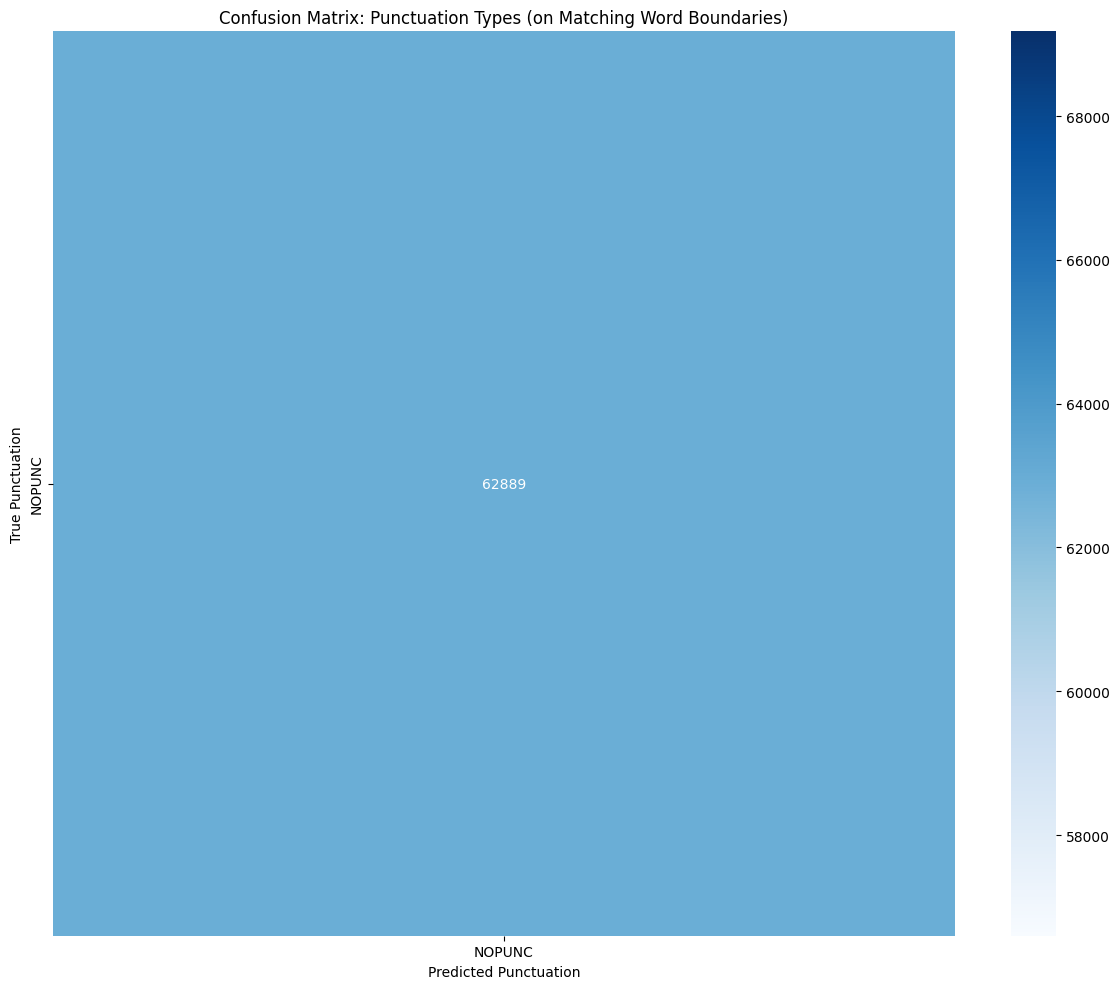


=== Top 5 cases: correct word boundary (at that point) but wrong punctuation type ===


In [10]:
from __future__ import annotations
from typing import List
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


def _punc_type_from_joint_tag(tag: str) -> str:
    # Joint tag dạng: 'B-W__COMMA' / 'I-W__NOPUNC'
    if '__' in tag:
        return tag.split('__', 1)[1]
    return 'OTHER'


def plot_punc_confusion_matrix(df_results) -> None:
    """
    Confusion matrix cho *loại dấu câu* ở những vị trí mà cả GT và Pred
    đều xác định là bắt đầu 1 từ (B-...), tức là boundary khớp tại điểm đó.
    """
    y_true: List[str] = []
    y_pred: List[str] = []

    for _, row in df_results.iterrows():
        t_tags = Metrics._joint_tags_from_full_text(row['gt_full'], CFG.puncs)
        p_tags = Metrics._joint_tags_from_full_text(row['pred_full'], CFG.puncs)

        min_len = min(len(t_tags), len(p_tags))
        t_tags = t_tags[:min_len]
        p_tags = p_tags[:min_len]

        for t, p in zip(t_tags, p_tags):
            if t.startswith('B-') and p.startswith('B-'):
                y_true.append(_punc_type_from_joint_tag(t))
                y_pred.append(_punc_type_from_joint_tag(p))

    if not y_true:
        print('[Warn] No overlapping B- positions to plot confusion matrix.')
        return

    labels = sorted(set(y_true) | set(y_pred))
    # Đưa NOPUNC lên đầu để dễ đọc (nếu có)
    if 'NOPUNC' in labels:
        labels = ['NOPUNC'] + [x for x in labels if x != 'NOPUNC']

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(12, 10))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=labels,
        yticklabels=labels,
    )
    plt.xlabel('Predicted Punctuation')
    plt.ylabel('True Punctuation')
    plt.title('Confusion Matrix: Punctuation Types (on Matching Word Boundaries)')
    plt.tight_layout()
    plt.show()


def analyze_pure_punc_errors(df_results, num_examples: int = 5) -> None:
    """
    In vài ví dụ: boundary tại một vị trí khớp (B- ở cả 2),
    nhưng loại dấu câu dự đoán khác ground-truth tại vị trí đó.
    """
    print(f'\n=== Top {num_examples} cases: correct word boundary (at that point) but wrong punctuation type ===')
    printed = 0

    for idx, row in df_results.iterrows():
        t_tags = Metrics._joint_tags_from_full_text(row['gt_full'], CFG.puncs)
        p_tags = Metrics._joint_tags_from_full_text(row['pred_full'], CFG.puncs)
        raw_chars = strip_punc_and_spaces(row['gt_full'])

        min_len = min(len(t_tags), len(p_tags), len(raw_chars))
        if min_len <= 0:
            continue

        error_details: List[str] = []
        for i in range(min_len):
            t = t_tags[i]
            p = p_tags[i]
            if not (t.startswith('B-') and p.startswith('B-')):
                continue

            t_type = _punc_type_from_joint_tag(t)
            p_type = _punc_type_from_joint_tag(p)
            if t_type != p_type:
                ch = raw_chars[i]
                error_details.append(f" '{ch}': True='{t_type}' vs Pred='{p_type}'")

        if not error_details:
            continue

        print(f'\nExample #{idx}:')
        print(f"Original: {row['original']}")
        print('Errors found: ' + ', '.join(error_details))
        print('-' * 50)

        printed += 1
        if printed >= num_examples:
            break


# --- Chạy ---
plot_punc_confusion_matrix(df)
analyze_pure_punc_errors(df)

<Figure size 1200x600 with 0 Axes>

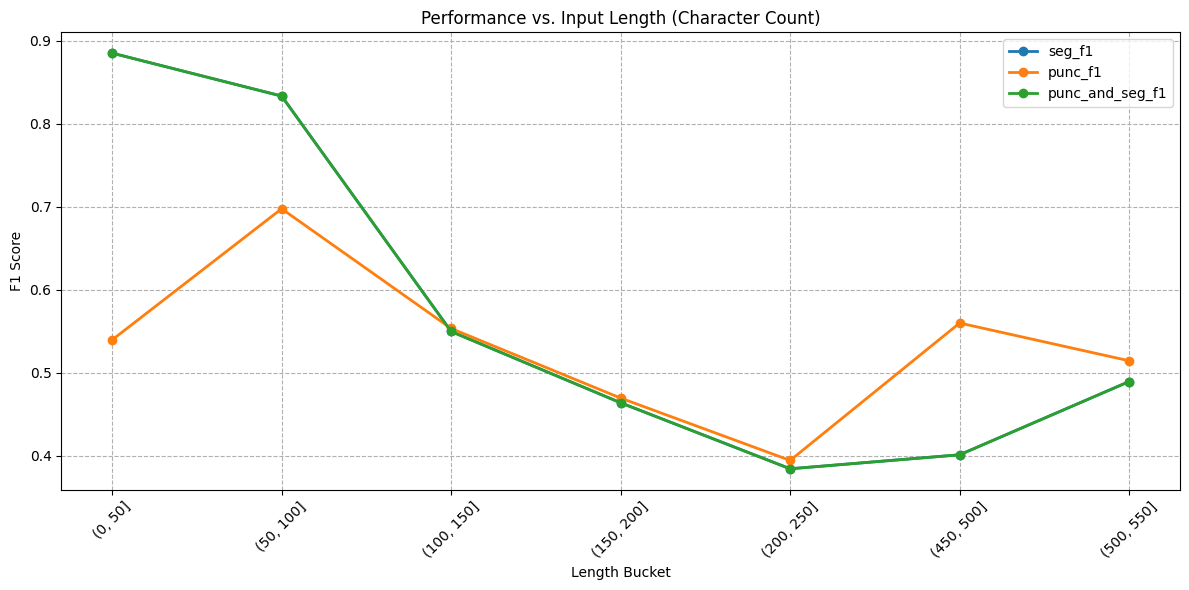

In [11]:
import matplotlib.pyplot as plt
import pandas as pd


def plot_performance_by_length(df_results, bin_size=50):
    # Tính độ dài character gốc cho mỗi mẫu
    df_results['char_len'] = df_results['original'].apply(len)
    
    # Chia bucket độ dài: 0-50, 50-100, 100-150...
    bins = range(0, df_results['char_len'].max() + bin_size, bin_size)
    df_results['len_bucket'] = pd.cut(df_results['char_len'], bins=bins)
    
    # Group by bucket và tính mean metrics
    grouped = df_results.groupby('len_bucket', observed=True)[['seg_f1', 'punc_f1', 'punc_and_seg_f1']].mean()
    
    # Vẽ biểu đồ đường
    plt.figure(figsize=(12, 6))
    grouped.plot(kind='line', marker='o', linewidth=2, figsize=(12, 6))
    plt.title('Performance vs. Input Length (Character Count)')
    plt.xlabel('Length Bucket')
    plt.ylabel('F1 Score')
    plt.grid(True, linestyle='--')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_performance_by_length(df)
# Nếu đường F1 đi ngang: Model ổn định tốt 
# Nếu đường F1 cắm đầu đi xuống ở các bucket cuối: Model bị lỗi context ở câu dài => cần tăng sliding window overlap